In [136]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [137]:
df1 = pd.read_csv("../dataset/Lucy_english_dataset.csv")
df2 = pd.read_csv("../dataset/lucy_hinghlish_dataset.csv")
df3 = pd.read_csv("../dataset/final_ai_genrated_hinglish_dataset.csv")

In [138]:
df = pd.concat([df1, df2, df3], ignore_index=True)

### Remving Broken Emojis

In [139]:
import re

def clean_text(text):
    text = str(text)
    
    # remove normal emojis
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text)
    
    # remove broken encoded emojis like ðŸ˜‚
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    
    return text

In [140]:

df["text"] = df["text"].apply(clean_text)

In [141]:
df["emotion"] = df["emotion"].str.lower().str.strip()

In [142]:
mapping = {
    
    #  HAPPY group
    "happiness": "happy",
    "joy": "happy",
    "happy": "happy",
    "fun": "happy",
    "smile": "happy",

    #  ANGER group
    "angry": "anger",
    "anger": "anger",
    "frustration": "anger",

    #  SAD group
    "sadness": "sad",
    "sad": "sad",
    "depressed": "sad",
    "upset": "sad",

    #  LOVE group
    "love": "love",
    "admiration": "love",
    "affection": "love",

    #  SURPRISE group
    "surprise": "surprise",
    "shocked": "surprise",

    #  HATE group
    "disgust": "hate",
    "disapproval": "hate",
    "hate": "hate",
    "annoyed": "hate",

    #  ENTHUSIASM group
    "enthusiasm": "enthusiasm",
    "excitement": "enthusiasm",
    "excited": "enthusiasm"
}

In [143]:
 # mapping
df["emotion"] = df["emotion"].map(mapping)

In [144]:
# remove unknown labels
df.dropna(subset=["emotion"], inplace=True)

In [145]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [146]:
df['emotion'].value_counts()

emotion
happy         23082
love          15769
hate          14693
anger         13023
sad           13020
surprise      11781
enthusiasm    10058
Name: count, dtype: int64

# EDA

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101426 entries, 0 to 101425
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   text     101426 non-null  str  
 1   emotion  101426 non-null  str  
dtypes: str(2)
memory usage: 1.5 MB


In [148]:
df.shape

(101426, 2)

In [149]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [150]:
df.duplicated().sum()

np.int64(21367)

In [151]:
df.duplicated(subset=["text"]).sum()

np.int64(21396)

In [152]:
conflicts = df.groupby("text")["emotion"].nunique()
conflicts = conflicts[conflicts > 1]

print(len(conflicts))

27


In [153]:
df.groupby("text")["emotion"].nunique().sort_values(ascending=False).head()


text
Thank you!                                                     3
FREE UNLIMITED RINGTONES!!! - - USA ONLY - Awesome 4 iphone    3
Happy Mothers Day                                              2
Certainly not .                                                2
happy mother's day                                             2
Name: emotion, dtype: int64

## Removing Duplucates

In [154]:
df = df.drop_duplicates()

In [155]:
df.duplicated().sum()


np.int64(0)

## Removing Conflict Text

In [156]:
valid_texts = df.groupby("text")["emotion"].nunique()
valid_texts = valid_texts[valid_texts == 1].index

df = df[df["text"].isin(valid_texts)]

In [157]:
df['emotion'].value_counts()

emotion
happy         18106
love          13988
sad           11966
hate          10861
anger         10132
surprise       9661
enthusiasm     5289
Name: count, dtype: int64

<Axes: xlabel='emotion', ylabel='count'>

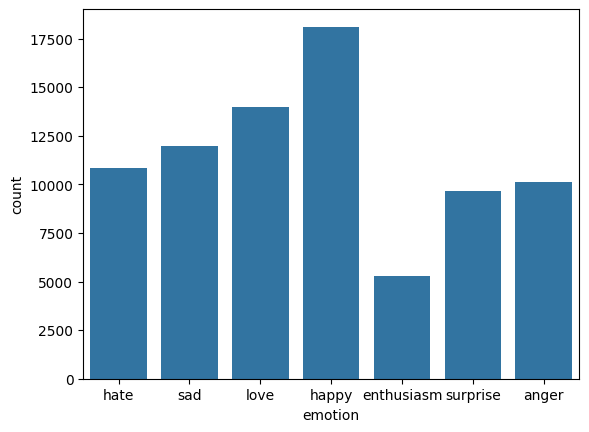

In [158]:
sns.countplot(x="emotion", data=df)

In [159]:
df["text_length"] = df["text"].apply(len)
df["text_length"].describe()

count    80003.000000
mean        94.987525
std         53.866706
min          3.000000
25%         54.000000
50%         86.000000
75%        123.000000
max        830.000000
Name: text_length, dtype: float64

# Train Test Split

In [160]:
X = df['text']
y = df['emotion']

In [161]:
from sklearn.model_selection import train_test_split

In [162]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y)

# Creating Pipeline

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

In [164]:
pipeline = Pipeline([
    ("tfidf" , TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    max_features = 15000,
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
    )),

    ("model" , LogisticRegression(
        max_iter=1000,
        C=1,
        class_weight='balanced',
        solver='lbfgs',
        verbose=1
    )),
])

In [165]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [166]:
y_predict = pipeline.predict(X_test)

# Classifiction Report and Accuracy

In [167]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

       anger       0.72      0.72      0.72      2027
  enthusiasm       0.89      0.85      0.87      1058
       happy       0.82      0.72      0.77      3621
        hate       0.67      0.75      0.71      2172
        love       0.83      0.83      0.83      2798
         sad       0.64      0.63      0.63      2393
    surprise       0.60      0.69      0.64      1932

    accuracy                           0.73     16001
   macro avg       0.74      0.74      0.74     16001
weighted avg       0.74      0.73      0.73     16001



In [168]:
accuracy_score(y_test,y_predict)

0.732829198175114

### Confusion Matriix

In [169]:
confusion_matrix(y_test,y_predict)

array([[1453,    2,   55,  221,   45,  141,  110],
       [   9,  898,   56,    3,    9,   33,   50],
       [  94,   50, 2612,  105,  190,  253,  317],
       [ 189,    4,   50, 1630,   65,  140,   94],
       [  46,    9,  108,  160, 2309,   75,   91],
       [ 155,   21,  160,  229,   98, 1496,  234],
       [  77,   22,  144,   93,   77,  191, 1328]])

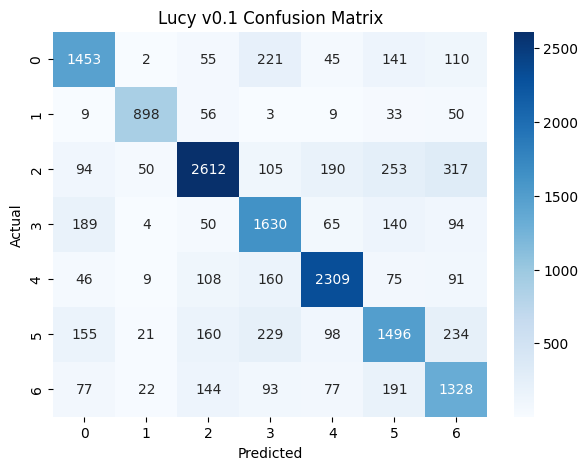

In [170]:

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Lucy v0.1 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Loading the emoji dataset

In [171]:
df_emoji = pd.read_csv("../dataset/emoji_emotions_final.csv")

In [172]:
df_emoji.head()

,emoji,emotion
0,😀,Happy
1,😃,Happy
2,😄,Happy
3,😁,Happy
4,😆,Happy


In [173]:
df_emoji.shape

(161, 2)

In [174]:
emoji_dict = dict(zip(df_emoji['emoji'],df_emoji['emotion']))

### Testing

In [175]:
text = ["i am happy 😁"]
predict = pipeline.predict(text)
print(predict)

['happy']


### Manual Testing

In [176]:
for char in text:
    print(char)

i am happy 😁


## Normalization Emojis

In [177]:
import unicodedata

In [178]:
def normalize_emoji(e):
    return unicodedata.normalize("NFKC",e)

## Extracting Emoji

In [179]:
import emoji

In [ ]:
def extract_emojis(text):
    return [c for c in text if c in emoji.EMOJI_DATA]

In [181]:
extract_emojis("hahaha 🥲")

['🥲']

## Emoji to Emotion Mapping

In [182]:
from collections import Counter


In [183]:
def get_emoji_emotion(text):
    emojis = extract_emojis(text)

    emotions = []

    for e in emojis:
        e = normalize_emoji(e)
        if e in emoji_dict:
            emotions.append(emoji_dict[e])

    if not emotions:
        return None
    
    return Counter(emotions).most_common(1)[0][0]

In [184]:
get_emoji_emotion("I am really happy 😊😭😔")

'Sad'

# Text + Emoji 

In [185]:
def get_text_emotion(text):
    prediction = pipeline.predict([text])[0]
    probabilities = pipeline.predict_proba([text])[0]
    confidence = max(probabilities)

    return prediction , confidence

In [186]:
emotion , confidence = get_text_emotion("i am very happy😭")
print("Emotion",emotion)
print("Confidence",confidence)

Emotion happy
Confidence 0.9615452073451282


### Fusion Function

In [187]:
def predict_final(text):
    text_emotion , text_confidence = get_text_emotion(text)
    emoji_emotion = get_emoji_emotion(text)

    if emoji_emotion is None:
        return text_emotion , text_confidence , "text_only"
    
    if text_confidence >=0.75:
        return text_emotion , text_confidence , "text_confident"
    
    elif text_confidence<=0.5 :
        return emoji_emotion ,text_confidence,"emoji_used"
    
    else:
        if text_emotion == emoji_emotion:
            return text_emotion,text_confidence,"aggrement"
        else:
            return "mixed",text_confidence,"conflicts"

In [196]:
predict_final(" i hate this 🤣")

('hate', np.float64(0.9997372686910573), 'text_confident')

### Creating Pickle File 

In [197]:
import joblib

In [198]:
joblib.dump(pipeline,"../models/lucy_pipeline_v0_2.pkl")


['../models/lucy_pipeline_v0_2.pkl']